<a href="https://colab.research.google.com/github/lukaszradlinski/UM25_26_SL_Lista_2/blob/main/UczenieMaszynowe_25_26_Lista2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Zbiorów Danych
Laboratorium polega na analizie eksploracynej oraz wykonaniu redukcji wymiarowości dwóch zbiorów danych. W trakcie ćwiczenia zbadasz wskazane zbiory danych w następujących zadaniach:

1. Dla obu zbiorów danych:
    * Wczytaj zbiór danych. Opisz poszczególne kolumny - jakie zawierają atrybuty, co opisują. Zdecyduj czy któreś z kolumn należy przekształcić.
    * Zweryfikuj, czy w zbiorze występują wartości brakujące i/lub odstające. Zdecyduj jak (i czy) należy je usunąć.
    * Zbadaj korelacje między zmiennymi. Możesz posłużyć się macierzą korelacji.
    * Zwizualizuj najciekawsze/najważniejsze według Ciebie zależności w zbiorze.
2. Tylko dla zbioru Spotify Tracks:
    * Utwórz nową cechę "emocja" na podstawie dostępnych kolumn.
    * Dokonaj redukcji wymiarowości za pomocą metod *filter* oraz *wrapper*.
    * Zwizualizij zbiór za pomocą PCA oraz t-SNE. Sprawdź, jak na wizualizację wpływa normalizacja oraz standaryzacja danych.


## Zaliczenie laboratorium


 Za zadania można uzyskać maksymalnie 10 punktów według poniższej tabeli:

| ID | Zadanie | Zbiór danych | Ilość punktów |
|----|---------|--------------|---------------|
| 1  |Wczytanie zbioru danych. Określenie typów zmiennych. Opis kolumn. | Titanic, Spotify | 1 pkt |
| 2  |Filtracja danych. Usunięcie brakujących wartości. | Titanic, Spotify | 2 pkt|
| 3  |Analiza korelacji między zmiennymi (korzystając m. in. z macierzy korelacji) | Titanic, Spotify | 2 pkt |
| 4  |Przedstawienie wizualizacji (histogramów, pudełkowych) opisujących dane. | Titanic, Spotify | 2 pkt |
| 5  |Inżynieria i redukcja cech. | Spotify |1 pkt|
| 6 | Wizualizacja zbioru przy redukcji wymiarów poprzez PCA / t-SNE. Analiza wyników. | Spotify | 2 pkt. |

Analizę (punkty 1-4) należy przeprowadzić dla obu zbiorów. Redukcja (5-6) powinna zostać wykonana tylko dla zbioru *Spotify Tracks*.

### Pytania pomocnicze:
- Co decyduje o jakości i trudności zbioru danych? Czy któryś ze zbiorów z ćwiczenia jest łatwiejszy/trudniejszy? Dlaczego?
- Jakie informacje daje nam analiza pojedynczych cech w przeciwieństwie do analizy wielowymiarowej?
- Jakie własności zbioru mogą stanowić problem dla analizy?
- Na czym polega detekcja wartości odstających? Jaki wpływ na wyniki ma wybrana metoda?
- Jakie są wady/zalety metod radzenia sobie z brakującymi wartościami?
- Jak działa PCA i kiedy warto go stosować?
- Jak działa t-SNE i kiedy warto go stosować? Jaka jest fundamentalna różnica względem PCA?
- Na czym polega standaryzacja danych oraz normalizacja danych? Jakie są różnice
pomiędzy tymi metodami?

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Analiza zbioru danych [*Titanic*](https://www.kaggle.com/competitions/titanic/overview)

10 kwietnia 1912 roku brytyjski transatlantyk Titanic wypływa z Southampton, a 5 dni później schodzi na dno Atlantyku. Z 2208 osób na pokładzie, ocalało jedynie 704 [[1](https://pl.wikipedia.org/wiki/RMS_Titanic#Liczba_ofiar)]. Szanse przeżycia były silnie uzależnione od płci czy klasy podróży.

Zbiór danych Titanic zawiera informacje o 891 pasażerach statku. Podaje on między innymi płeć, klasę podróży, czy numer biletu. Celem tej części listy jest przeanalizowanie zbioru, opisanie wartości w nim występujących, i odpowiedź na pytanie: kto miał największe szanse na przeżycie Titanica?

## Opis danych

In [30]:
# wczytanie zbioru danych
titanic = pd.read_csv("data/titanic/titanic.csv")

titanic.shape

(891, 12)

In [31]:
# MIEJSCE NA TWÓJ KOD
print(titanic.head(1))

print("\n--- Typy zmiennych ---")
print(titanic.dtypes)

print("\n--- Podstawowe statystyki ---")
print(titanic.describe(include='all'))

   PassengerId  Survived  Pclass                     Name   Sex   Age  SibSp  \
0            1         0       3  Braund, Mr. Owen Harris  male  22.0      1   

   Parch     Ticket  Fare Cabin Embarked  
0      0  A/5 21171  7.25   NaN        S  

--- Typy zmiennych ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

--- Podstawowe statystyki ---
        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000    0.383838    2.3

## Opis kolumn

| Kolumna | Typ | Opis |
|---|---|---|
| `PassengerId` | int | Unikalny identyfikator pasażera — do usunięcia |
| `Survived` | int (0/1) | Zmienna docelowa: 1 = przeżył, 0 = nie przeżył |
| `Pclass` | int (1/2/3) | Klasa biletu — zmienna porządkowa |
| `Name` | str | Imię i nazwisko — do usunięcia (zbyt unikalne) |
| `Sex` | str | Płeć — wymaga label encodingu (male/female → 0/1) |
| `Age` | float | Wiek — 177 brakujących wartości (NaN) |
| `SibSp` | int | Liczba rodzeństwa/współmałżonków na pokładzie |
| `Parch` | int | Liczba rodziców/dzieci na pokładzie |
| `Ticket` | str | Numer biletu — do usunięcia|
| `Fare` | float | Cena biletu |
| `Cabin` | str | Numer kabiny — 687 brakujących NaN, do uproszczenia |
| `Embarked` | str | Port zaokrętowania (S/C/Q) — 2 brakujące, wymaga encodingu |


## Przekształcenie danych

In [32]:
# MIEJSCE NA TWÓJ KOD
titanic = titanic.drop(columns=['PassengerId', 'Name', 'Ticket'])
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Cabin'] = titanic['Cabin'].notnull().astype(int)

print(titanic.head())
print(titanic.dtypes)

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Cabin Embarked
0         0       3    0  22.0      1      0   7.2500      0        S
1         1       1    1  38.0      1      0  71.2833      1        C
2         1       3    1  26.0      0      0   7.9250      0        S
3         1       1    1  35.0      1      0  53.1000      1        S
4         0       3    0  35.0      0      0   8.0500      0        S
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin         int64
Embarked     object
dtype: object


## Brakujące wartości

Wskazówki:
- Wartości ciągłe możemy zinterpolować korzystając z gotowej metody [`pandas.DataFrame.interpolate`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)
- Wartości dyskretne można uzupełnić konkretną wartością używając metody [`pandas.DataFrame.fillna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Aby lepiej ocenić czym uzupełnić NaNy, warto wyświetlić kolumnę na wykresie.
- W przypadku dyskretnych wartości, warto również znaleźć wartości unikatowe funkcją `unique()`.

### Wiek pasażera

In [33]:
# MIEJSCE NA TWÓJ KOD
titanic = titanic.sort_values('Age').reset_index(drop=True)
titanic['Age'] = titanic['Age'].interpolate(method='linear')

In [34]:
assert titanic['Age'].isnull().values.any() == False, "Kolumna 'wiek' zawiera brakujące wartości"


### Zaokrętowanie

In [35]:
# MIEJSCE NA TWÓJ KOD
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic['Embarked'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [36]:
assert titanic['Embarked'].isnull().values.any() == False, "Kolumna 'zaokrętowanie' zawiera brakujące wartości"

### Kabina

In [ ]:
# MIEJSCE NA TWÓJ KOD

In [22]:
assert titanic['Cabin'].isnull().values.any() == False, "Kolumna 'kabina' zawiera brakujące wartości"

In [23]:
assert titanic.isnull().values.any() == False, "Zbiór danych zawiera brakujące wartości"

## Przedstawienie danych na wykresach

Wybierz 3-4 wykresy które przekazują według Ciebie najwięcej informacji.

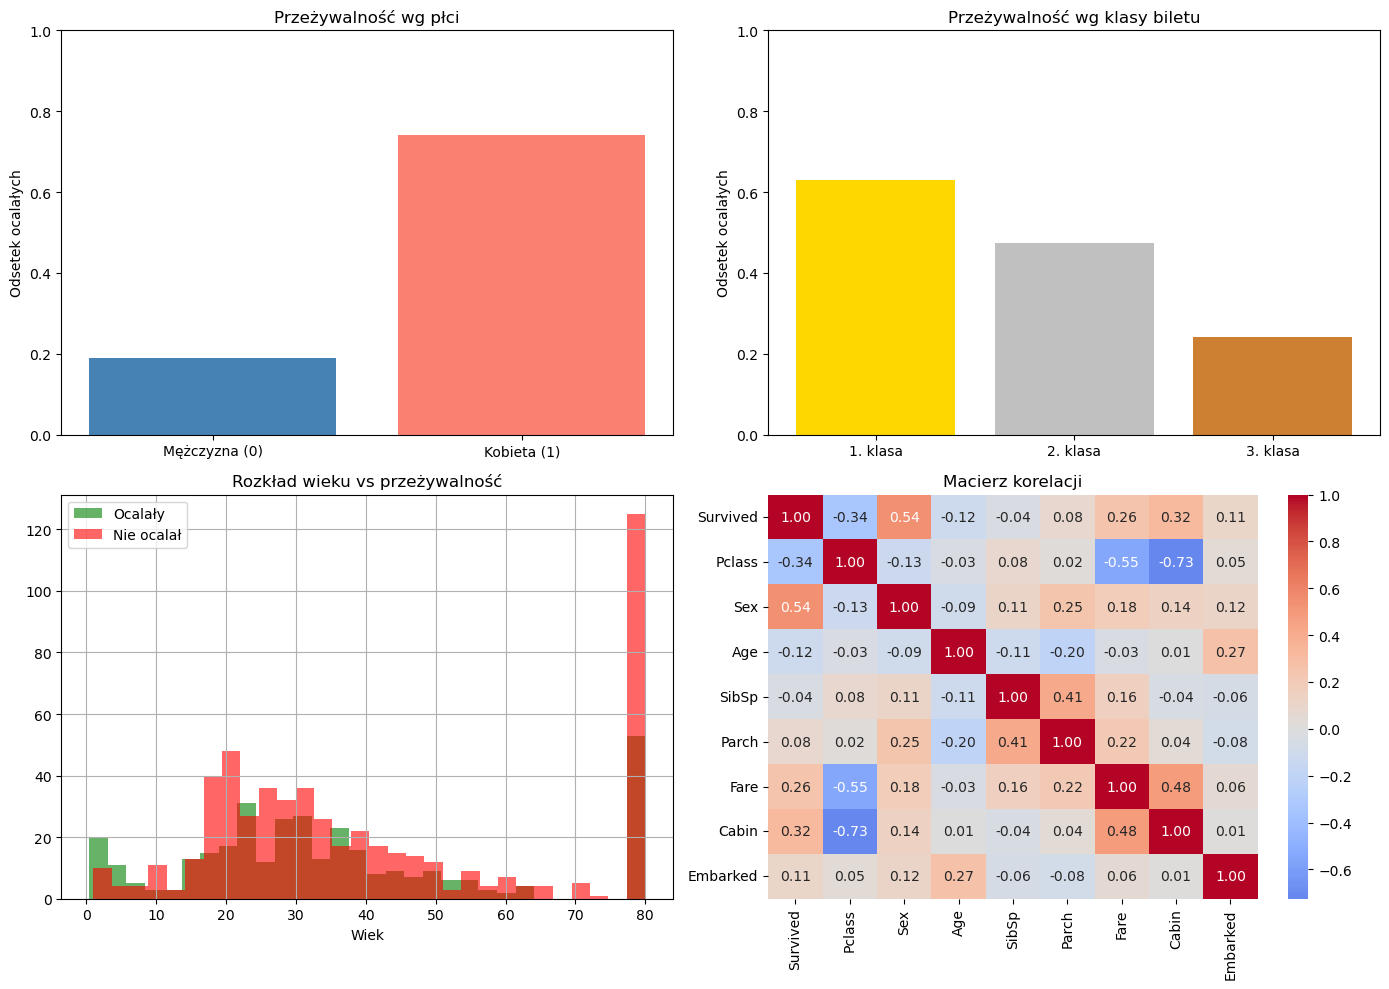

In [38]:
# MIEJSCE NA TWÓJ KOD
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
survival_sex = titanic.groupby('Sex')['Survived'].mean()
axes[0, 0].bar(['Mężczyzna (0)', 'Kobieta (1)'], survival_sex.values, color=['steelblue', 'salmon'])
axes[0, 0].set_title('Przeżywalność wg płci')
axes[0, 0].set_ylabel('Odsetek ocalałych')
axes[0, 0].set_ylim(0, 1)

survival_class = titanic.groupby('Pclass')['Survived'].mean()
axes[0, 1].bar(['1. klasa', '2. klasa', '3. klasa'], survival_class.values, color=['gold', 'silver', '#cd7f32'])
axes[0, 1].set_title('Przeżywalność wg klasy biletu')
axes[0, 1].set_ylabel('Odsetek ocalałych')
axes[0, 1].set_ylim(0, 1)

titanic[titanic['Survived'] == 1]['Age'].hist(ax=axes[1, 0], bins=30, alpha=0.6, label='Ocalały', color='green')
titanic[titanic['Survived'] == 0]['Age'].hist(ax=axes[1, 0], bins=30, alpha=0.6, label='Nie ocalał', color='red')
axes[1, 0].set_title('Rozkład wieku vs przeżywalność')
axes[1, 0].set_xlabel('Wiek')
axes[1, 0].legend()

corr = titanic.corr(numeric_only=True)
sns.heatmap(corr, ax=axes[1, 1], annot=True, fmt='.2f', cmap='coolwarm', center=0)
axes[1, 1].set_title('Macierz korelacji')

plt.tight_layout()
plt.show()

## Podsumowanie - ocena przeżywalności

Na podstawie informacji uzyskanych podczas ćwiczenia - kto miał największe szanse przeżyć Titanica? Jaka cecha (bądź zestaw cech) decydowały o wyniku podróży?

In [40]:
# MIEJSCE NA TWÓJ KOD
print("=== Podsumowanie - kto przeżył Titanica? ===\n")

s = titanic.groupby('Sex')['Survived'].mean()
print(f"Kobiety (1): {s[1]:.1%} przeżyło")
print(f"Mężczyźni (0): {s[0]:.1%} przeżyło\n")

s2 = titanic.groupby('Pclass')['Survived'].mean()
for cls, val in s2.items():
    print(f"Klasa {cls}: {val:.1%} przeżyło")

print("\nWnioski:")
print("- Kobiety miały znacznie wyższy wskaźnik przeżywalności niż mężczyźni (zasada 'kobiety i dzieci pierwsze').")
print("- Pasażerowie 1. klasy przeżywali znacznie częściej niż 3. klasy.")
print("- Posiadanie kabiny koreluje z wyższą klasą i przeżywalnością.")
print("- Dzieci miały wyższe szanse przeżycia.")

=== Podsumowanie - kto przeżył Titanica? ===

Kobiety (1): 74.2% przeżyło
Mężczyźni (0): 18.9% przeżyło

Klasa 1: 63.0% przeżyło
Klasa 2: 47.3% przeżyło
Klasa 3: 24.2% przeżyło

Wnioski:
- Kobiety miały znacznie wyższy wskaźnik przeżywalności niż mężczyźni (zasada 'kobiety i dzieci pierwsze').
- Pasażerowie 1. klasy przeżywali znacznie częściej niż 3. klasy.
- Posiadanie kabiny koreluje z wyższą klasą i przeżywalnością.
- Dzieci miały wyższe szanse przeżycia.


# Analiza zbioru danych [*Spotify Tracks*](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

Celem tej części listy jest analiza dużego, rzeczywistego zbioru danych zawierającego informacje o ponad 100 tysiącach piosenek ze Spotify. Zbiór zawiera kilkanaście cech numerycznych opisujących utwór oraz cechy kategoryczne: wykonawcę, nazwę albumu, gatunek.

Analiza zbioru pozwoli w późniejszym etapie na skuteczną redukcję wymiarowości za pomocą dwóch metod: *filter* oraz *wrapper*. Końcowym celem listy jest przedstawienie wielowymiarowego zbioru na dwuwymiarowym wykresie za pomocą `PCA` oraz `tSNE`.

## Opis danych

In [41]:
spotify = pd.read_csv("data/spotify/data.csv")

spotify.shape

(170653, 19)

In [43]:
# MIEJSCE NA TWÓJ KOD
print(spotify.head(1))
print("\n--- Typy zmiennych ---")
print(spotify.dtypes)
print("\n--- Podstawowe statystyki ---")
print(spotify.describe(include='all'))
print(f"\nKształt: {spotify.shape}")
print(f"\nBrakujące wartości:\n{spotify.isnull().sum()}")

   valence  year  acousticness  \
0   0.0594  1921         0.982   

                                             artists  danceability  \
0  ['Sergei Rachmaninoff', 'James Levine', 'Berli...         0.279   

   duration_ms  energy  explicit                      id  instrumentalness  \
0       831667   0.211         0  4BJqT0PrAfrxzMOxytFOIz             0.878   

   key  liveness  loudness  mode  \
0   10     0.665   -20.096     1   

                                                name  popularity release_date  \
0  Piano Concerto No. 3 in D Minor, Op. 30: III. ...           4         1921   

   speechiness   tempo  
0       0.0366  80.954  

--- Typy zmiennych ---
valence             float64
year                  int64
acousticness        float64
artists              object
danceability        float64
duration_ms           int64
energy              float64
explicit              int64
id                   object
instrumentalness    float64
key                   int64
liveness       

## Przekształcenia i filtracja danych

In [44]:
# MIEJSCE NA TWÓJ KOD
spotify_clean = spotify.drop(columns=['id', 'name', 'artists', 'release_date'], errors='ignore')
spotify_clean = spotify_clean.drop_duplicates()
spotify_clean = spotify_clean.dropna()

print(f"Rozmiar po czyszczeniu: {spotify_clean.shape}")
print(f"Brakujące wartości: {spotify_clean.isnull().sum().sum()}")
print(spotify_clean.dtypes)

Rozmiar po czyszczeniu: (169903, 15)
Brakujące wartości: 0
valence             float64
year                  int64
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
explicit              int64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
popularity            int64
speechiness         float64
tempo               float64
dtype: object


## Wizualizacje

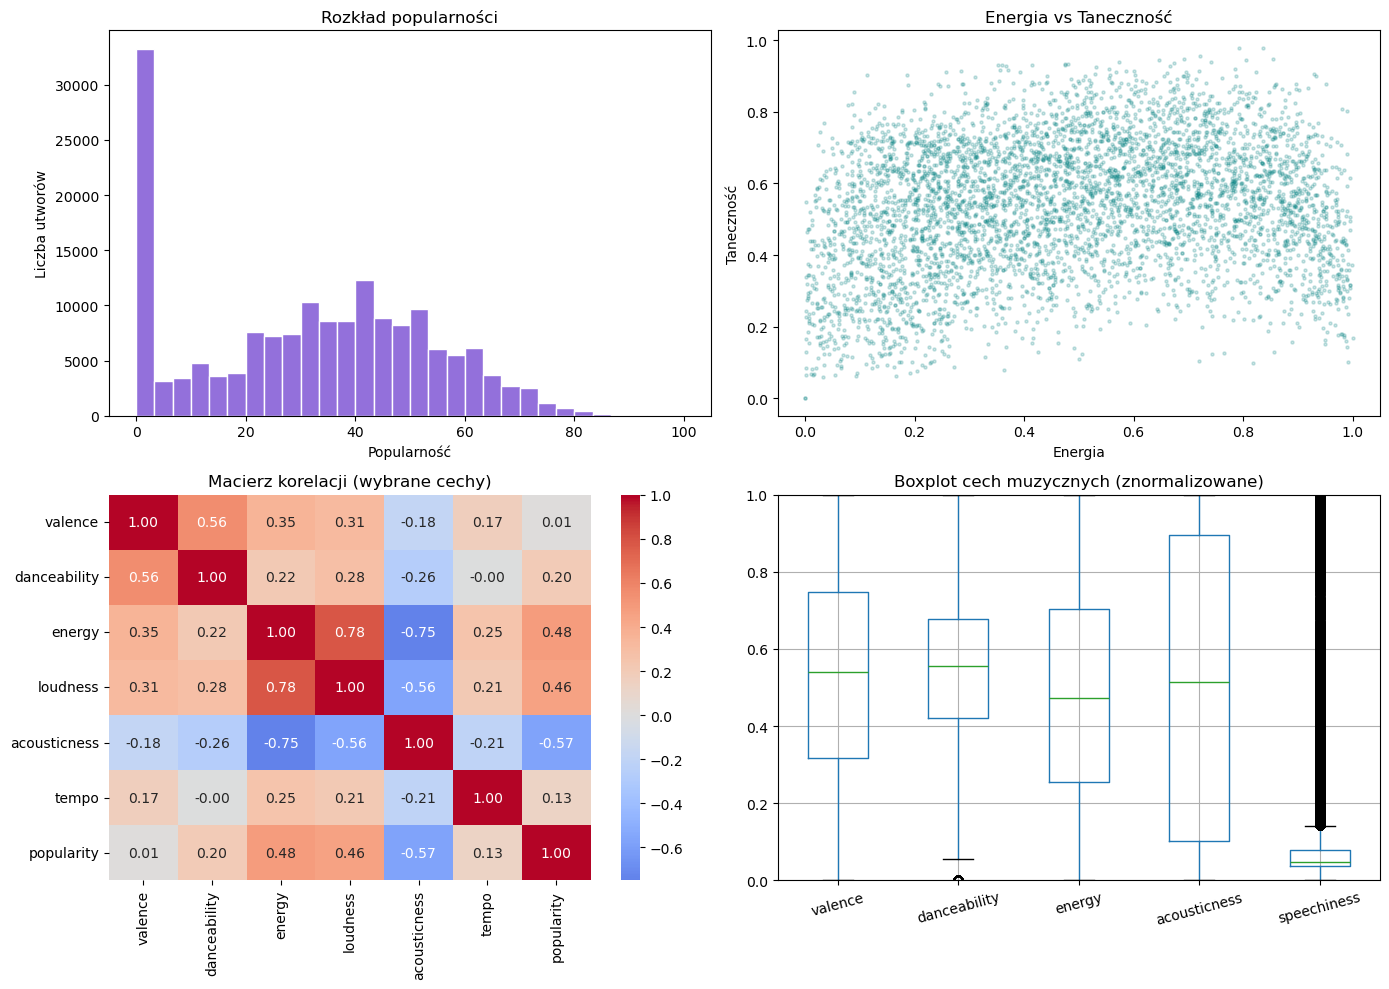

In [ ]:
# MIEJSCE NA TWÓJ KOD
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(spotify_clean['popularity'], bins=30, color='mediumpurple', edgecolor='white')
axes[0, 0].set_title('Rozkład popularności')
axes[0, 0].set_xlabel('Popularność')
axes[0, 0].set_ylabel('Liczba utworów')

sample = spotify_clean.sample(5000, random_state=42)
axes[0, 1].scatter(sample['energy'], sample['danceability'], alpha=0.2, color='teal', s=5)
axes[0, 1].set_title('Energia vs Taneczność')
axes[0, 1].set_xlabel('Energia')
axes[0, 1].set_ylabel('Taneczność')

num_cols = ['valence', 'danceability', 'energy', 'loudness', 'acousticness', 'tempo', 'popularity']
corr_s = spotify_clean[num_cols].corr()
sns.heatmap(corr_s, ax=axes[1, 0], annot=True, fmt='.2f', cmap='coolwarm', center=0)
axes[1, 0].set_title('Macierz korelacji (wybrane cechy)')

box_cols = ['valence', 'danceability', 'energy', 'acousticness', 'speechiness']
box_data = spotify_clean[box_cols].copy()
box_data = (box_data - box_data.min()) / (box_data.max() - box_data.min()) 
box_data.boxplot(ax=axes[1, 1])
axes[1, 1].set_title('Boxplot cech muzycznych (znormalizowane)')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Dodanie nowej cechy - emocja

Emocje w muzyce są przekazywane za pomocą akordów. W zbiorze mamy dostępne informacje nt. klucza i mody piosenki. Ich kombinacja będzie odpowiadać emocji, zgodnie z [tą rozpiską](https://ledgernote.com/blog/interesting/musical-key-characteristics-emotions/).

Moda w zbiorze jest określona jako 0 lub 1, co odpowiada *minor* i odpowiednio *major*.

Klucz jest w [notacji liczbowej](https://en.wikipedia.org/wiki/Pitch_class), czyli 0 odpowiada **C**, 1 odpowiada **C#**, itd.

Twoim zadaniem jest dodanie nowej kolumny "emotion" na podstawie dostępnych informacji.

In [46]:
# dla ułatwienia - gotowe słowniki

key_map = {0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F', 6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'}

emotion_map = {
    ('C', 'Major'):  'Happy',
    ('C#', 'Major'): 'Joyful',
    ('D', 'Major'):  'Triumphant',
    ('D#', 'Major'): 'Cruel',
    ('E', 'Major'):  'Noisy',
    ('F', 'Major'):  'Passionate',
    ('F#', 'Major'): 'Bright',
    ('G', 'Major'):  'Rustic',
    ('G#', 'Major'): 'Rich',
    ('A', 'Major'):  'Pastoral',
    ('A#', 'Major'): 'Magnificent',
    ('B', 'Major'):  'Harsh',

    ('C', 'Minor'):  'Sad',
    ('C#', 'Minor'): 'Melancholic',
    ('D', 'Minor'):  'Pensive',
    ('D#', 'Minor'): 'Anxious',
    ('E', 'Minor'):  'Grieving',
    ('F', 'Minor'):  'Tragic',
    ('F#', 'Minor'): 'Gloomy',
    ('G', 'Minor'):  'Serious',
    ('G#', 'Minor'): 'Mournful',
    ('A', 'Minor'):  'Tender',
    ('A#', 'Minor'): 'Dark',
    ('B', 'Minor'):  'Lonely',
}

In [47]:
# MIEJSCE NA TWÓJ KOD
mode_map = {0: 'Minor', 1: 'Major'}

spotify_clean['key_name'] = spotify_clean['key'].map(key_map)
spotify_clean['mode_name'] = spotify_clean['mode'].map(mode_map)
spotify_clean['emotion'] = spotify_clean.apply(
    lambda row: emotion_map.get((row['key_name'], row['mode_name']), 'Unknown'), axis=1
)

print(spotify_clean['emotion'].value_counts())
spotify_clean = spotify_clean.drop(columns=['key_name', 'mode_name'])

emotion
Happy          17380
Rustic         16586
Triumphant     14644
Pastoral       11736
Passionate     10794
Joyful          9523
Rich            8708
Magnificent     7840
Noisy           7335
Tender          5782
Lonely          5735
Cruel           5641
Tragic          5569
Grieving        5546
Bright          5071
Harsh           4881
Dark            4239
Sad             4138
Serious         4130
Pensive         4096
Gloomy          3625
Melancholic     3312
Mournful        1988
Anxious         1604
Name: count, dtype: int64


## Redukcja wymiarowości

W tej części zadania należy:
- zredukować wymiary zbioru poprzez usunięcie wybranych kolumn korzystając z metod *filter* i *wrapper*
- zwizualizować zbiór danych korzystając z metod redukcji wymiarowości
- zaimplementować standaryzację oraz normalizację
- przeanalizować jak te działania wpływają na wyniki redukcji



### Filter
Analizując pojedyncze kolumny, zdecyduj czy któreś z nich należy usunąć.

In [ ]:
# MIEJSCE NA TWÓJ KOD
from sklearn.feature_selection import VarianceThreshold

num_features = spotify_clean.select_dtypes(include='number').columns.tolist()
num_features = [f for f in num_features if f != 'popularity']

selector = VarianceThreshold(threshold=0.01)
selector.fit(spotify_clean[num_features])
low_var = [f for f, keep in zip(num_features, selector.get_support()) if not keep]
print(f"Cechy o niskiej wariancji: {low_var}")

corr_matrix = spotify_clean[num_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.75)]
print(f"Cechy wysoko skorelowane (>0.75): {high_corr}")

to_drop = list(set(low_var + high_corr))
spotify_filtered = spotify_clean.drop(columns=to_drop, errors='ignore')
print(f"Rozmiar po filter: {spotify_filtered.shape}")

Cechy o niskiej wariancji: []
Cechy wysoko skorelowane (>0.75): ['loudness']
Rozmiar po filter: (169903, 15)


### Wrapper
Korzystając z gotowej implementacji klasyfikatora las losowy, zdecyduj czy któreś z kolumn należy usunąć.

**UWAGA**

To jest bardzo uproszczona implementacja wrappera, która ma na celu jedynie pokazać jego działanie.

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

def classify(df, features):
    """
    Dostępne cechy:
        'valence', 'year', 'acousticness', 'artists', 'danceability',
        'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key',
        'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date',
        'speechiness', 'tempo'
    """
    df = df.drop(columns=["Unnamed: 0", "track_id", "artists", "album_name", "track_name"], errors="ignore")
    df["explicit"] = df["explicit"].astype(int)
    df = df.sample(10000, random_state=42).dropna()

    df["popularity_bracket"] = pd.cut(df["popularity"], bins=[0, 33, 66, 100], labels=["low", "mid", "high"])
    df = df.dropna(subset=["popularity_bracket"])
    y = LabelEncoder().fit_transform(df["popularity_bracket"])
    X = df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42))
    ])
    pipe.fit(X_train, y_train)

    acc  = pipe.score(X_test, y_test)

    print(f"Features  : {features}")
    print(f"Test Acc  : {acc:.4f}")
    return acc

In [55]:
# WYWOŁAJ KLASYFIKATOR W TYM MIEJSCU
all_feats = ["duration_ms", "explicit", "danceability", "energy", "key", 
             "loudness", "mode", "speechiness", "acousticness",
             "instrumentalness", "liveness", "valence", "tempo"]

base_acc = classify(spotify, all_feats)
results = {}
for feat in all_feats:
    reduced = [f for f in all_feats if f != feat]
    acc = classify(spotify, reduced)
    results[feat] = base_acc - acc

print("\n--- Ważność cech (spadek accuracy po usunięciu) ---")
for feat, drop in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{feat:20s}: {drop:+.4f}")

to_remove_wrapper = [f for f, drop in results.items() if drop <= 0]
print(f"\nCechy do usunięcia (wrapper): {to_remove_wrapper}")

Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Test Acc  : 0.6945
Features  : ['explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Test Acc  : 0.6879
Features  : ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Test Acc  : 0.6993
Features  : ['duration_ms', 'explicit', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Test Acc  : 0.6933
Features  : ['duration_ms', 'explicit', 'danceability', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
Test Acc  : 0.6969
Features  : ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 

### Wizualizacje (PCA i t-SNE)

W wizualizacji przetestuj kilka kolumn jako docelowe.

In [56]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import preprocessing

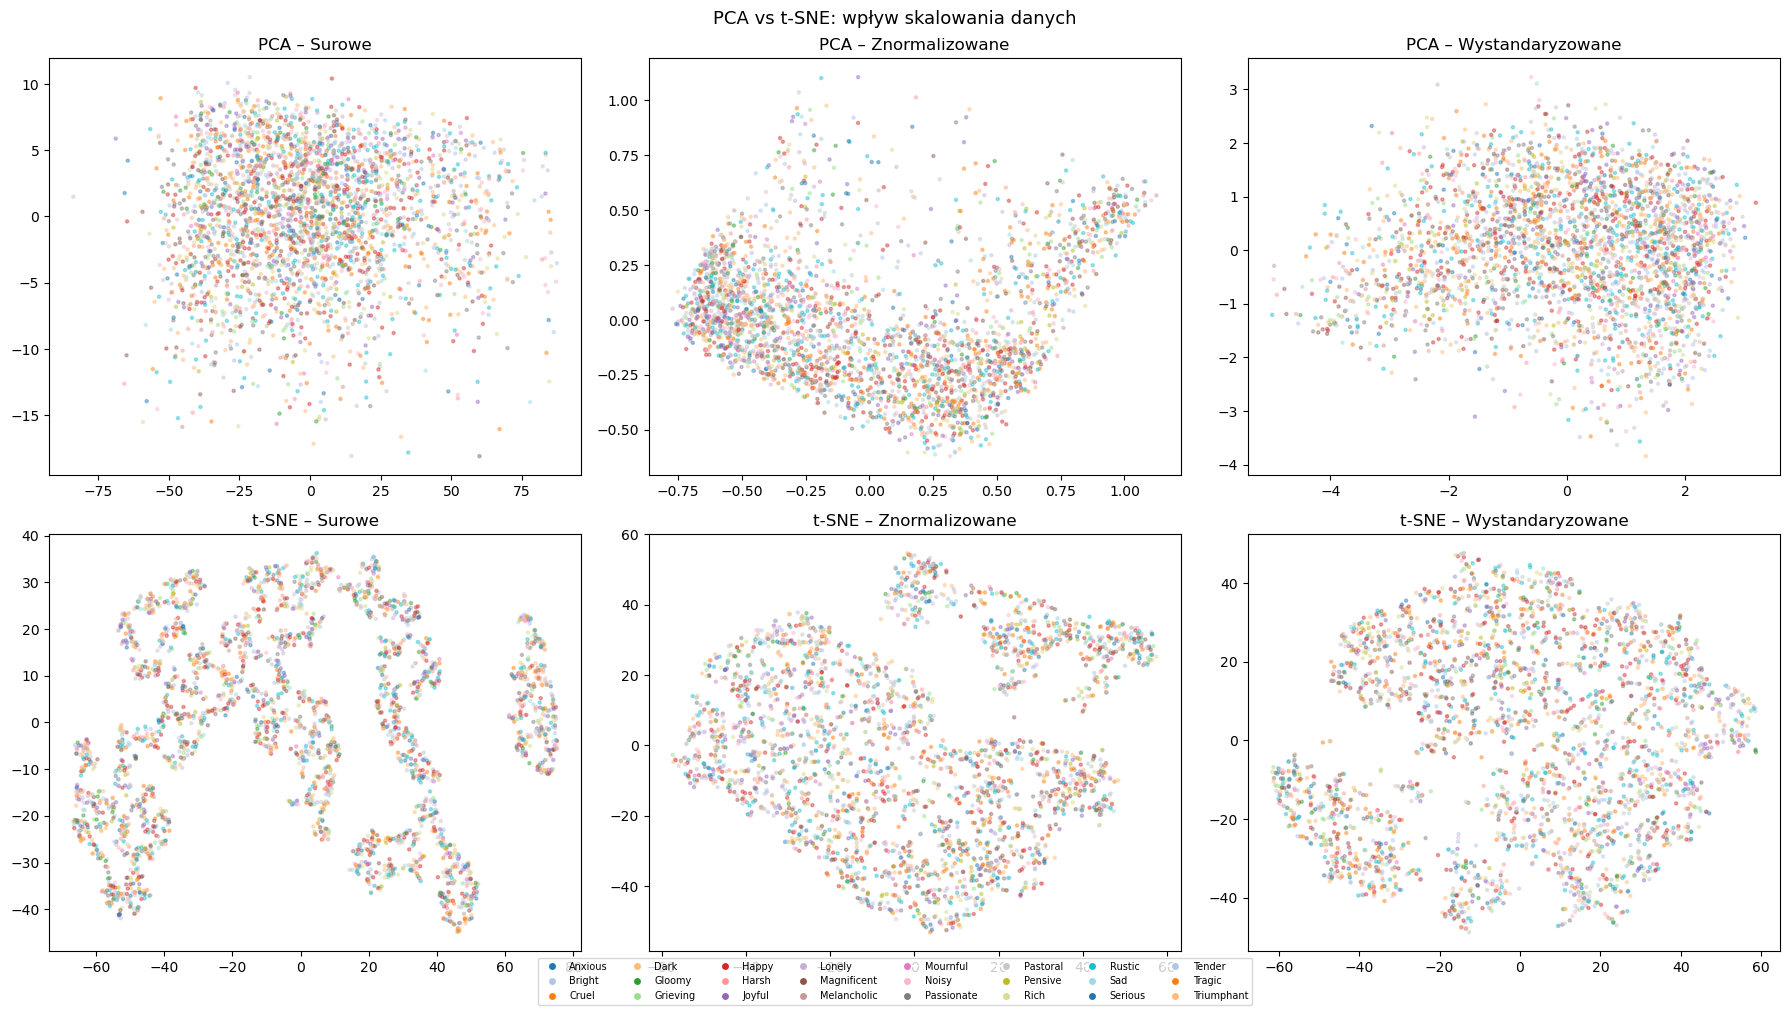

In [58]:
# przykładowe funkcje
feature_cols = ["danceability", "energy", "loudness", "speechiness", 
                "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

sample = spotify_clean[feature_cols + ['emotion']].dropna().sample(3000, random_state=42)
X = sample[feature_cols].values
y = sample['emotion'].values

def dataframe_xy(df):
    X = df[feature_cols].values
    y = df['emotion'].values
    return X, y

# normalize to [0,1] range
def normalize(X):
    return preprocessing.MinMaxScaler().fit_transform(X)

# standarize (e.g, w/ scikit standard scaler)
def standarize(X):
    return preprocessing.StandardScaler().fit_transform(X)

# remove outliers
def remove_outliers(X, y):
    mask = np.all(np.abs(preprocessing.StandardScaler().fit_transform(X)) < 3, axis=1)
    return X[mask], y[mask]

emotions_unique = sorted(set(y))
palette = dict(zip(emotions_unique, sns.color_palette("tab20", len(emotions_unique))))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
configs = [("Surowe", X), ("Znormalizowane", normalize(X)), ("Wystandaryzowane", standarize(X))]

for col, (title, X_proc) in enumerate(configs):
    X_c, y_c = remove_outliers(X_proc, y)
    colors = [palette[e] for e in y_c]

    X_pca = PCA(n_components=2).fit_transform(X_c)
    axes[0, col].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=5)
    axes[0, col].set_title(f'PCA – {title}')

    X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_c)
    axes[1, col].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.4, s=5)
    axes[1, col].set_title(f't-SNE – {title}')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[e], markersize=6) 
           for e in emotions_unique]
fig.legend(handles, emotions_unique, loc='lower center', ncol=8, fontsize=7, 
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('PCA vs t-SNE: wpływ skalowania danych', fontsize=13)
plt.tight_layout()
plt.show()
